In [ ]:
# evaluate random forest algorithm for classification
from numpy import mean
from numpy import std


## 建立模擬分類資料集

In [ ]:
# test regression dataset
from sklearn.datasets import make_classification
# define dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=3)
# summarize the dataset
print(X.shape, y.shape)

(1000, 20) (1000,)


### Logistic Regression Model

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
lg_model = LogisticRegression()
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
scores = cross_val_score(lg_model, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
print(scores)
print(f"{scores.mean():.2}")

[0.84 0.84 0.84 0.79 0.86 0.85 0.85 0.86 0.81 0.83 0.83 0.81 0.87 0.81
 0.81 0.93 0.81 0.86 0.81 0.85 0.81 0.81 0.85 0.89 0.79 0.86 0.85 0.9
 0.86 0.74]
0.84


### Decision Tree model

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.tree import DecisionTreeClassifier

In [ ]:
tree = DecisionTreeClassifier()

In [ ]:
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
scores = cross_val_score(tree, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
print(scores)
print(f"{scores.mean():.2}")

[0.82 0.83 0.84 0.75 0.78 0.71 0.72 0.81 0.81 0.8  0.82 0.83 0.86 0.73
 0.69 0.78 0.82 0.84 0.75 0.82 0.79 0.75 0.82 0.82 0.83 0.8  0.8  0.76
 0.82 0.73]
0.79


### random forest model

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rfc = RandomForestClassifier()

In [ ]:

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
scores = cross_val_score(rfc, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
print(scores)
print(f"{scores.mean():.2}")

[0.91 0.9  0.91 0.86 0.9  0.94 0.94 0.91 0.91 0.91 0.93 0.91 0.94 0.87
 0.93 0.92 0.89 0.93 0.88 0.89 0.91 0.87 0.89 0.93 0.84 0.9  0.92 0.9
 0.94 0.87]
0.91


Logistic Regression = 0.84

Decision Tree (CART) = 0.79

Random Forest = 0.91

## Hyperparameter Tuning

### grid search

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
rfc = RandomForestClassifier()

In [ ]:
param_grid = {"n_estimators": [200, 400, 600]}

In [ ]:
grid_search = GridSearchCV(estimator=rfc, param_grid=param_grid, cv=5, n_jobs=-1)


In [ ]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'n_estimators': [200, 400, 600]})

In [ ]:
print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'n_estimators': 400}


In [ ]:
import pandas as pd

result = pd.DataFrame(grid_search.cv_results_)
result.head()


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.461857,0.333119,0.041564,0.011027,200,{'n_estimators': 200},0.88750,0.90000,0.89375,0.88750,0.88125,0.89000,0.006374,2
1,2.464107,0.434683,0.059426,0.005002,400,{'n_estimators': 400},0.91250,0.91250,0.88750,0.90000,0.86875,0.89625,0.016583,1
2,3.742617,0.558433,0.082669,0.016616,600,{'n_estimators': 600},0.90625,0.90625,0.88125,0.89375,0.86250,0.89000,0.016583,2


### multiple parameter search

In [ ]:
param_grid = {
    "n_estimators": [500, 1000, 1500],
    "max_depth": [2, 4, 5],
    "min_samples_split": [2, 5]
}

In [ ]:
grid_search = GridSearchCV(estimator=rfc, param_grid=param_grid, cv=5, n_jobs=-1)

In [ ]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [2, 4, 5], 'min_samples_split': [2, 5],
                         'n_estimators': [500, 1000, 1500]})

In [ ]:
print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 500}


## 因子重要性

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rfc = RandomForestClassifier()

In [ ]:
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
scores = cross_val_score(rfc, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
print(scores)
print(f"{scores.mean():.2}")

[0.89 0.9  0.89 0.87 0.91 0.93 0.92 0.91 0.9  0.91 0.92 0.9  0.9  0.86
 0.94 0.92 0.89 0.92 0.86 0.86 0.93 0.86 0.92 0.94 0.89 0.92 0.9  0.89
 0.95 0.88]
0.9


In [ ]:
rfc.fit(X_train, y_train)
importance = rfc.feature_importances_
for i, v in enumerate(importance):
    print(f"feature: {i} score: {v}")

feature: 0 score: 0.04669761290813334
feature: 1 score: 0.033822723420188466
feature: 2 score: 0.028347168608735124
feature: 3 score: 0.03278671570944702
feature: 4 score: 0.04510053123295132
feature: 5 score: 0.14005375145334023
feature: 6 score: 0.09775725992499282
feature: 7 score: 0.0475783910775355
feature: 8 score: 0.054375297552217636
feature: 9 score: 0.039747294677163626
feature: 10 score: 0.10598119214130663
feature: 11 score: 0.03203320235634968
feature: 12 score: 0.04293129569755005
feature: 13 score: 0.023675109123512568
feature: 14 score: 0.02669226138137936
feature: 15 score: 0.023334700136352523
feature: 16 score: 0.039421349042634245
feature: 17 score: 0.03890576362159253
feature: 18 score: 0.03692763917042947
feature: 19 score: 0.06383074076418777


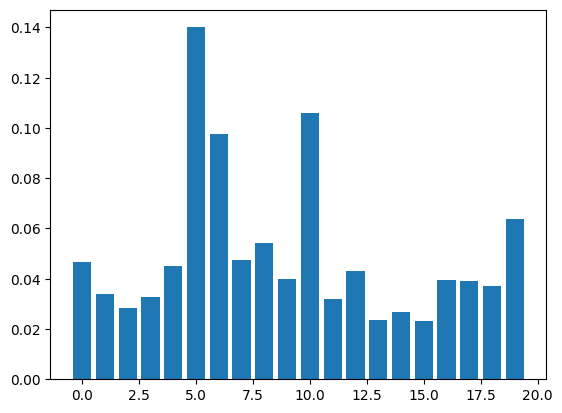

In [ ]:
import matplotlib.pyplot as plt
plt.bar([x for x in range(len(importance))], importance)
plt.show()

In [ ]:
import numpy as np
np.sort(importance)

array([0.0233347 , 0.02367511, 0.02669226, 0.02834717, 0.0320332 ,
       0.03278672, 0.03382272, 0.03692764, 0.03890576, 0.03942135,
       0.03974729, 0.0429313 , 0.04510053, 0.04669761, 0.04757839,
       0.0543753 , 0.06383074, 0.09775726, 0.10598119, 0.14005375])

In [ ]:
importance

array([0.0233347 , 0.02367511, 0.02669226, 0.02834717, 0.0320332 ,
       0.03278672, 0.03382272, 0.03692764, 0.03890576, 0.03942135,
       0.03974729, 0.0429313 , 0.04510053, 0.04669761, 0.04757839,
       0.0543753 , 0.06383074, 0.09775726, 0.10598119, 0.14005375])

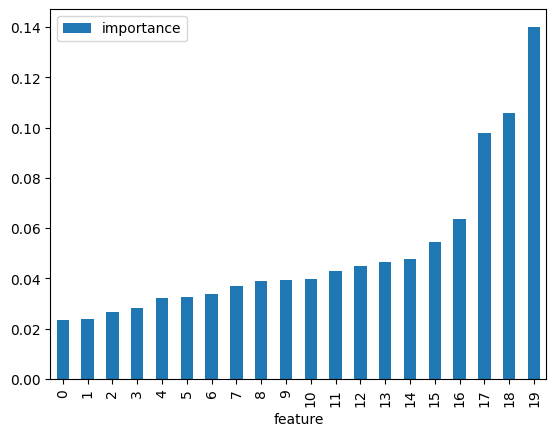

In [ ]:
imp = pd.DataFrame({
    "feature": [x for x in range(len(importance))],
    "importance": importance
})
imp.plot(kind="bar", x="feature", y="importance")
plt.show()
